# Job Market Analysis — Remote Data Roles
**Source:** RemoteOK API  
**Roles:** Data Analyst · Data Scientist · Data Engineer · ML Engineer · BI Developer

In [1]:
import os
os.makedirs("images", exist_ok=True)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = sns.color_palette('Set2', 10)

df = pd.read_csv('data.csv', parse_dates=['posting_date'])
print(f'Loaded {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Loaded 8 rows x 7 columns


,job_title,company,location,salary,skills,posting_date,job_link
0,C C++ Linux developer,Tempesta Technologies,Remote,"$40,000 - $100,000","senior, Algorithms, Data structures, linux",2026-03-14,https://remoteOK.com/remote-jobs/remote-c-c-li...
1,BPM LLP AI ML Engineer,Bpm Llp,United Kingdom,Not specified,"design, engineer, digital nomad",2026-03-12,https://remoteOK.com/remote-jobs/remote-bpm-ll...
2,Senior Software Engineer Data Platform,Zus Health,United States,Not specified,"software, embedded, system, ceo, technical, di...",2026-03-12,https://remoteOK.com/remote-jobs/remote-senior...
3,Data Analyst,Marketing Architects,Remote,"$70,000 - $90,000","analyst, support, growth, director, marketing,...",2026-03-12,https://remoteOK.com/remote-jobs/remote-data-a...
4,Contract Data Architect,The Motley Fool,United States,Not specified,"architect, support, financial, investment, str...",2026-03-12,https://remoteOK.com/remote-jobs/remote-contra...


In [2]:
# Basic overview
print(df.dtypes)
print()
print(df.isnull().sum())
print()
print(f'Date range: {df["posting_date"].min().date()} to {df["posting_date"].max().date()}')

job_title                  str
company                    str
location                   str
salary                     str
skills                     str
posting_date    datetime64[us]
job_link                   str
dtype: object

job_title       0
company         0
location        0
salary          0
skills          0
posting_date    0
job_link        0
dtype: int64

Date range: 2026-03-07 to 2026-03-14


## Most In-Demand Job Titles

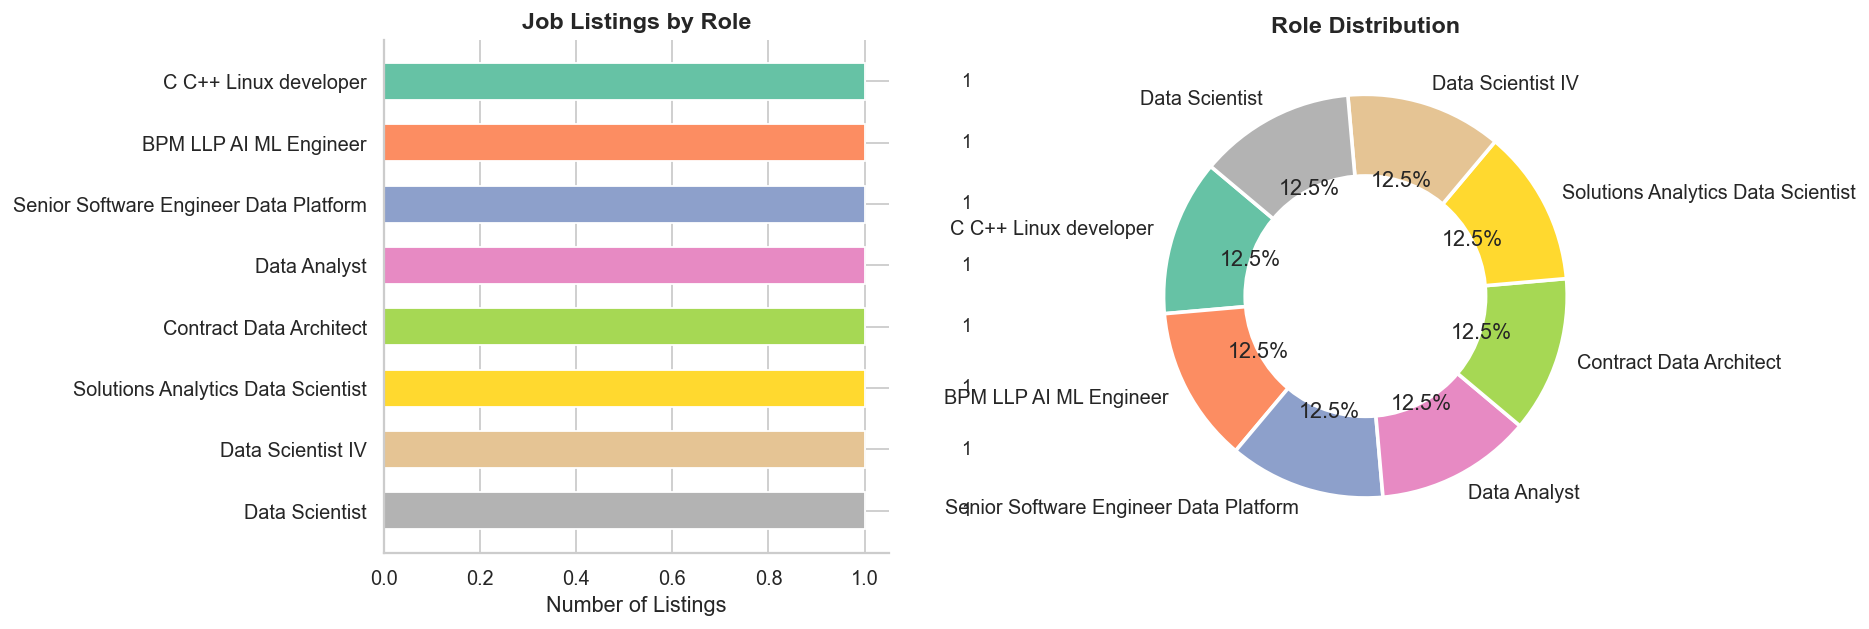

In [3]:
title_counts = df['job_title'].value_counts().reset_index()
title_counts.columns = ['job_title', 'count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].barh(title_counts['job_title'], title_counts['count'],
                    color=COLORS[:len(title_counts)], edgecolor='white', height=0.6)
axes[0].set_title('Job Listings by Role')
axes[0].set_xlabel('Number of Listings')
axes[0].invert_yaxis()
for bar in bars:
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                 str(int(bar.get_width())), va='center', fontsize=10)

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    title_counts['count'], labels=title_counts['job_title'],
    autopct='%1.1f%%', colors=COLORS[:len(title_counts)],
    startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].add_patch(plt.Circle((0, 0), 0.6, fc='white'))
axes[1].set_title('Role Distribution')

plt.tight_layout()
plt.savefig('images/chart_job_titles.png', bbox_inches='tight')
plt.show()

## Top Hiring Companies

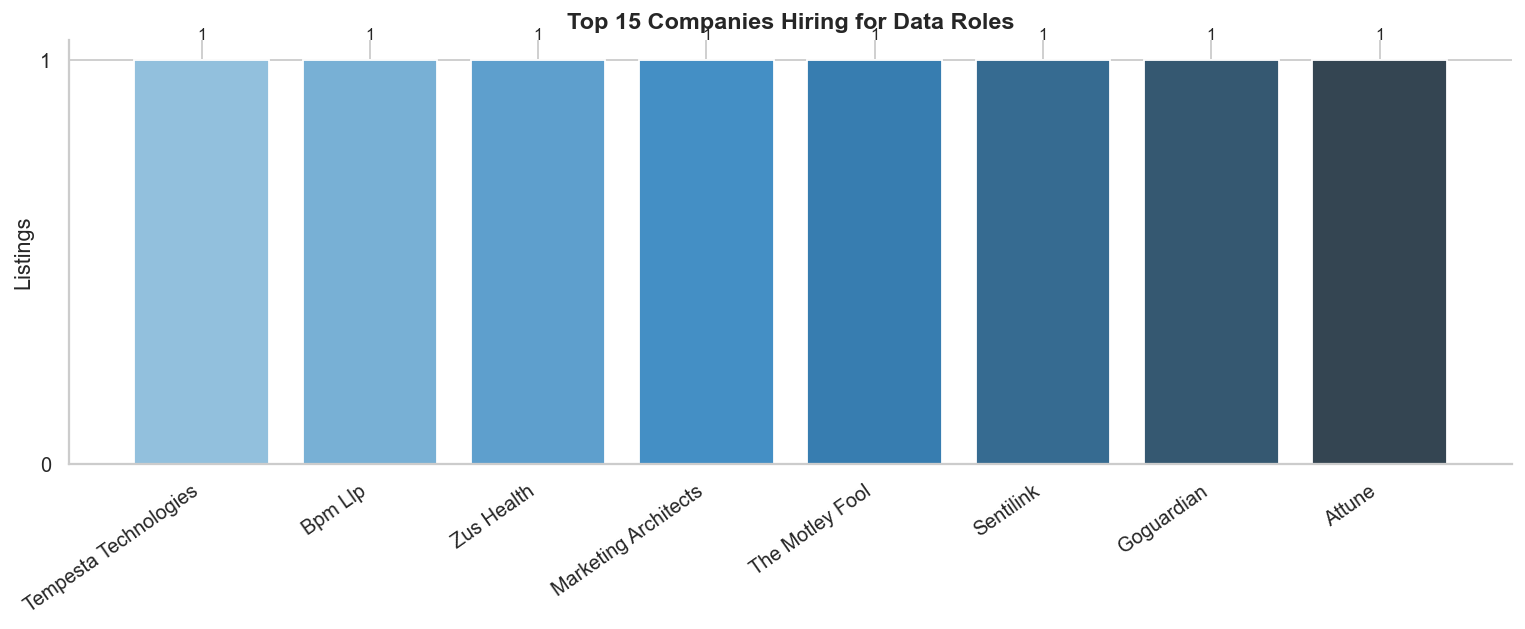

In [4]:
top_companies = df['company'].value_counts().head(15).reset_index()
top_companies.columns = ['company', 'count']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_companies['company'], top_companies['count'],
              color=sns.color_palette('Blues_d', len(top_companies)), edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            str(int(bar.get_height())), ha='center', fontsize=9)

ax.set_title('Top 15 Companies Hiring for Data Roles')
ax.set_ylabel('Listings')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('images/chart_top_companies.png', bbox_inches='tight')
plt.show()

## Jobs by Location

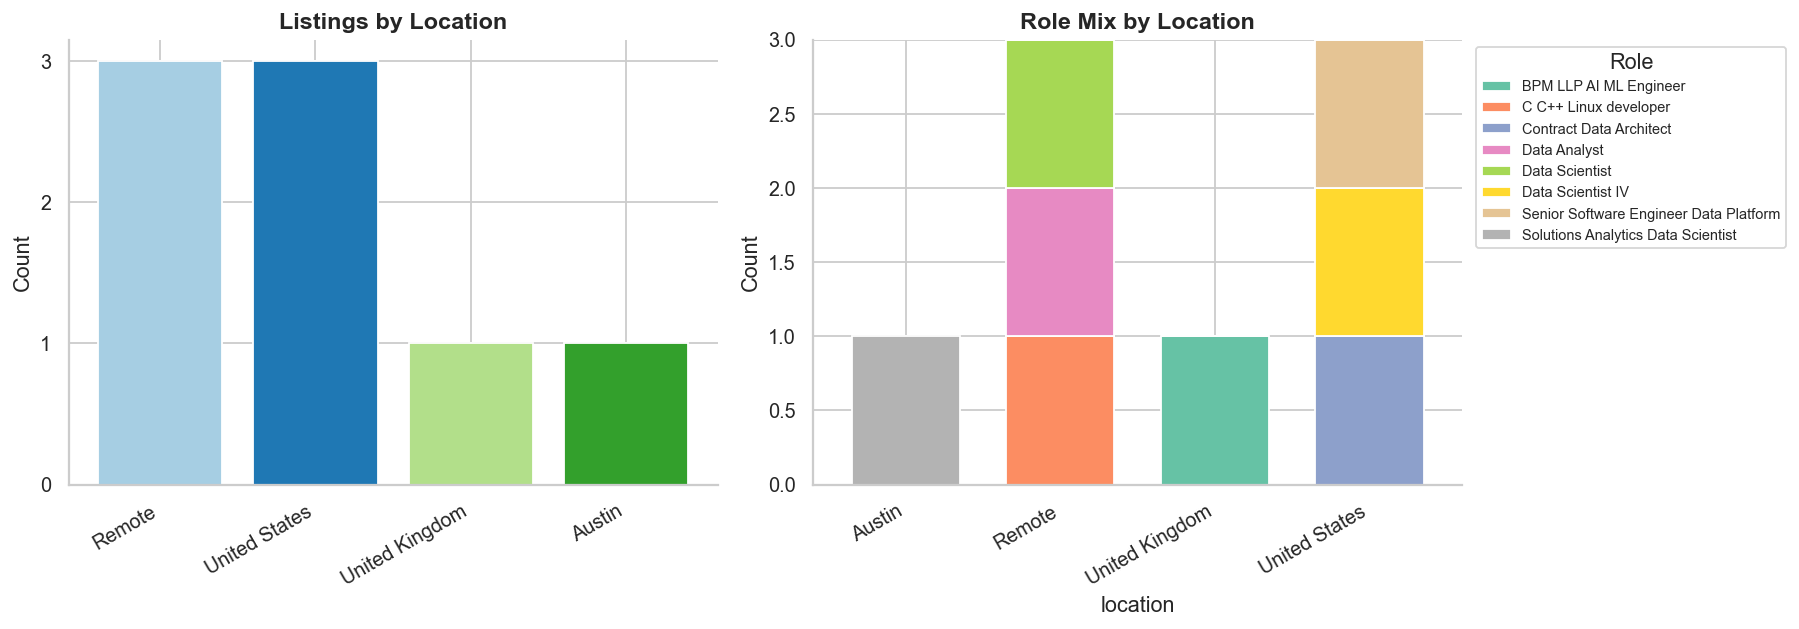

In [5]:
location_counts = df['location'].value_counts().reset_index()
location_counts.columns = ['location', 'count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(location_counts['location'], location_counts['count'],
            color=sns.color_palette('Paired', len(location_counts)), edgecolor='white')
axes[0].set_title('Listings by Location')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Stacked bar — location x role
loc_title = df.groupby(['location', 'job_title']).size().unstack(fill_value=0)
loc_title.plot(kind='bar', stacked=True, ax=axes[1],
               color=COLORS[:len(loc_title.columns)], edgecolor='white', width=0.7)
axes[1].set_title('Role Mix by Location')
axes[1].set_ylabel('Count')
axes[1].legend(title='Role', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('images/chart_locations.png', bbox_inches='tight')
plt.show()

## Salary Distribution

In [6]:
def parse_salary(s):
    if not s or s == 'Not specified':
        return None
    s = s.replace('$', '').replace(',', '')
    if ' - ' in s:
        parts = s.split(' - ')
        try: return (float(parts[0]) + float(parts[1])) / 2
        except: return None
    return None

df['salary_mid'] = df['salary'].apply(parse_salary)
df_sal = df[df['salary_mid'].notna()]

print(f'Jobs with salary: {len(df_sal)} ({len(df_sal)/len(df)*100:.1f}%)')
print(df_sal.groupby('job_title')['salary_mid'].mean().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))

Jobs with salary: 2 (25.0%)
job_title
Data Analyst             $80,000
C C++ Linux developer    $70,000
Name: salary_mid, dtype: str


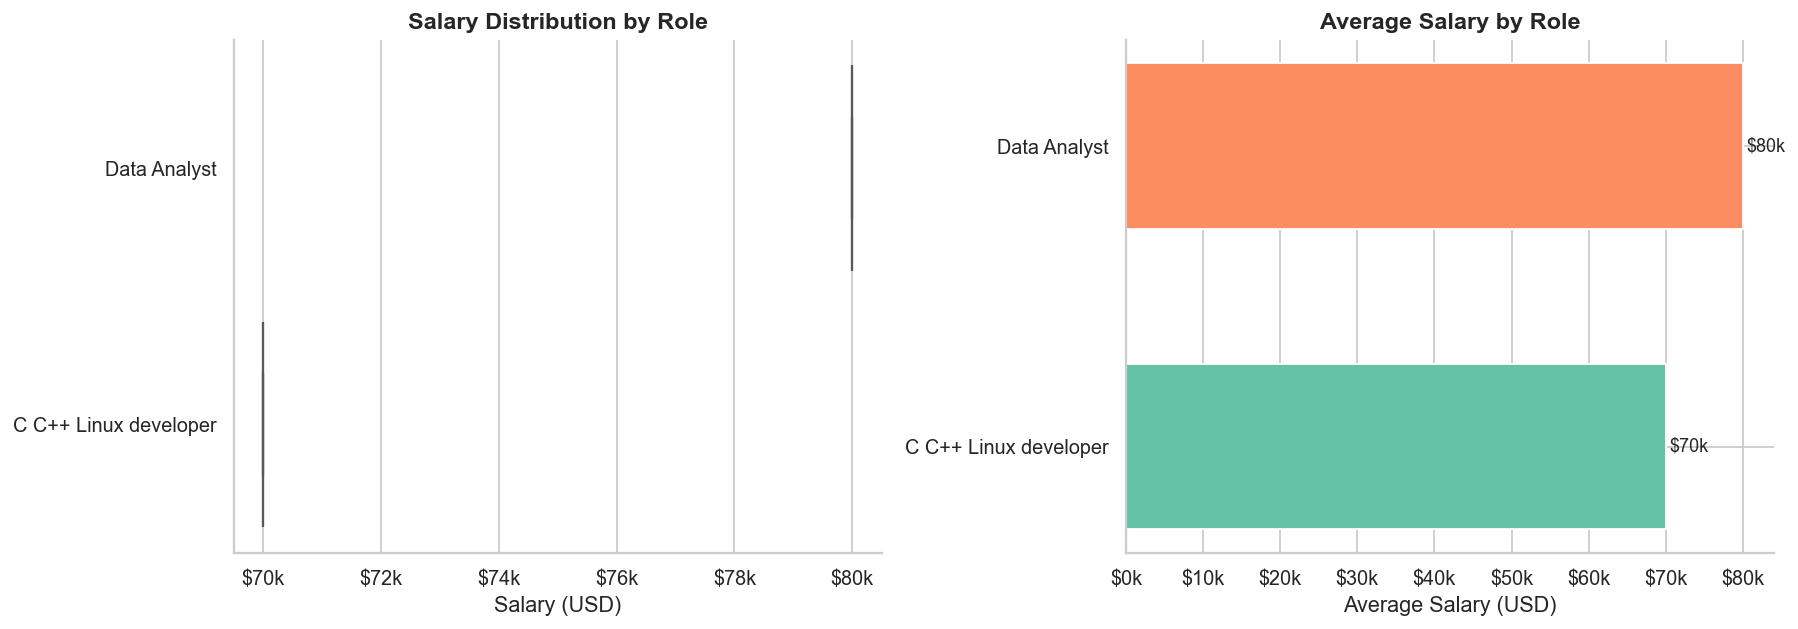

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
order = df_sal.groupby('job_title')['salary_mid'].median().sort_values(ascending=False).index
sns.boxplot(data=df_sal, x='salary_mid', y='job_title', order=order,
            palette='Set2', ax=axes[0], linewidth=1.2)
axes[0].set_title('Salary Distribution by Role')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Average salary bar
avg_sal = df_sal.groupby('job_title')['salary_mid'].mean().sort_values().reset_index()
bars = axes[1].barh(avg_sal['job_title'], avg_sal['salary_mid'],
                    color=COLORS[:len(avg_sal)], edgecolor='white', height=0.55)
for bar in bars:
    axes[1].text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
                 f'${bar.get_width()/1000:.0f}k', va='center', fontsize=10)
axes[1].set_title('Average Salary by Role')
axes[1].set_xlabel('Average Salary (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('images/chart_salary.png', bbox_inches='tight')
plt.show()

## Most In-Demand Skills

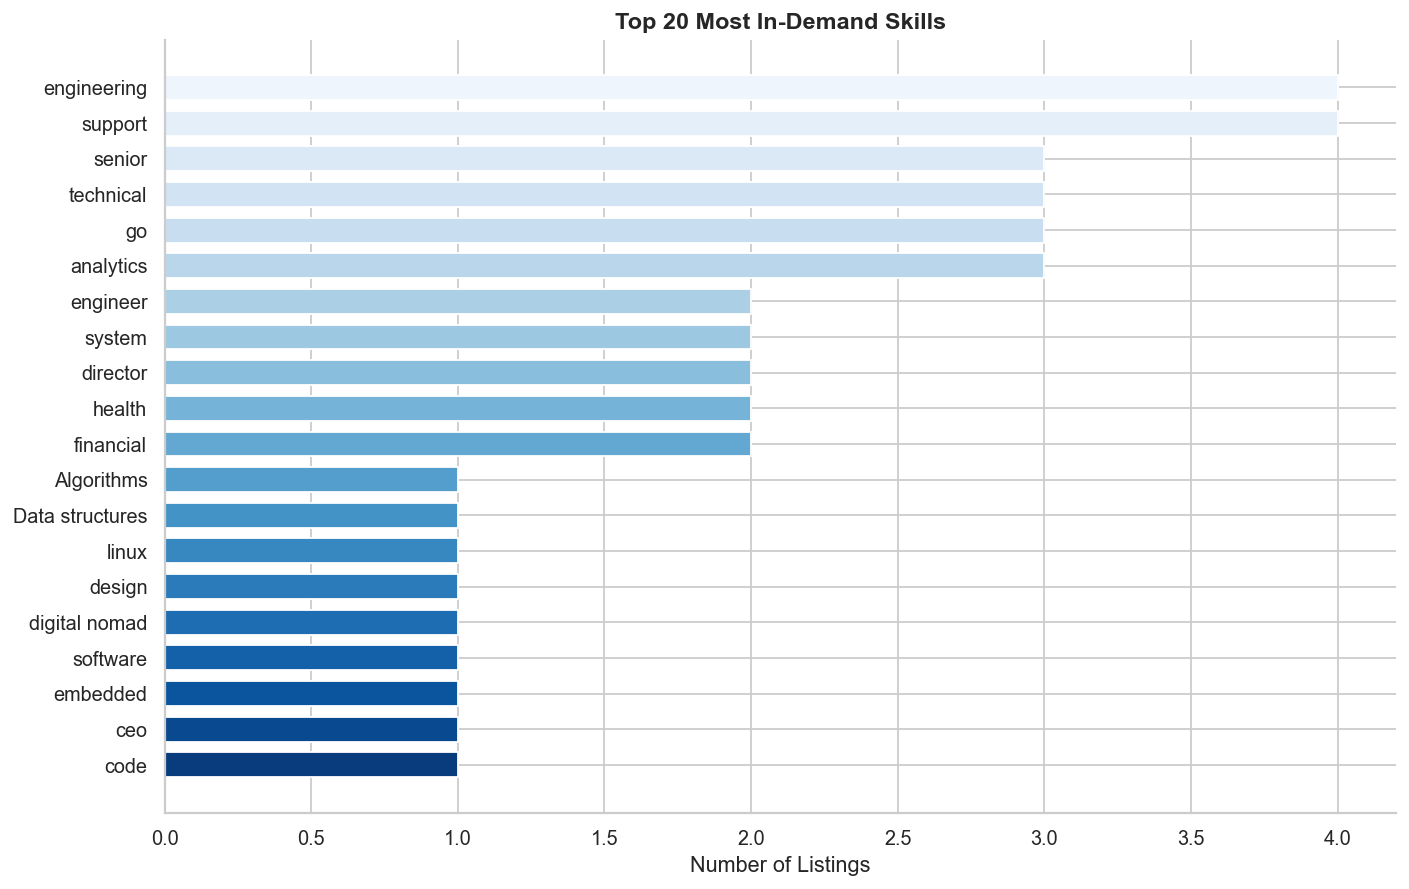

In [8]:
all_skills = df['skills'].dropna().apply(
    lambda x: [s.strip() for s in x.split(',') if s.strip() != 'Not specified']
)
skill_counts = Counter(s for skills in all_skills for s in skills)
top_skills = pd.DataFrame(skill_counts.most_common(20), columns=['skill', 'count'])

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_skills['skill'][::-1], top_skills['count'][::-1],
        color=sns.color_palette('Blues_r', len(top_skills)), edgecolor='white', height=0.7)
ax.set_title('Top 20 Most In-Demand Skills')
ax.set_xlabel('Number of Listings')
plt.tight_layout()
plt.savefig('images/chart_top_skills.png', bbox_inches='tight')
plt.show()

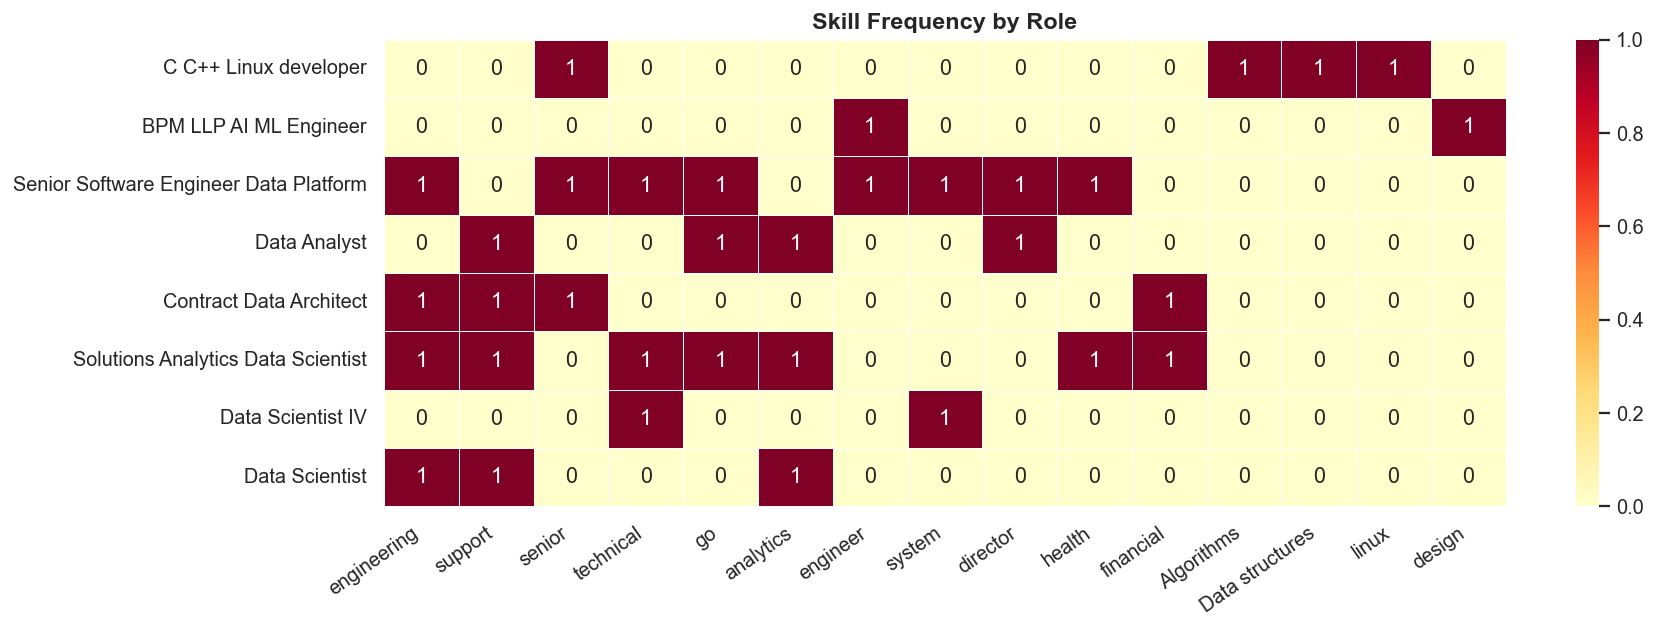

In [9]:
# Skill heatmap — role vs top 15 skills
top_15 = [s for s, _ in skill_counts.most_common(15)]
heatmap_data = {}
for role in df['job_title'].unique():
    role_skills = df[df['job_title'] == role]['skills'].dropna().apply(
        lambda x: [s.strip() for s in x.split(',')]
    )
    c = Counter(s for sl in role_skills for s in sl)
    heatmap_data[role] = {skill: c.get(skill, 0) for skill in top_15}

heatmap_df = pd.DataFrame(heatmap_data).T

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_df, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Skill Frequency by Role')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('images/chart_skill_heatmap.png', bbox_inches='tight')
plt.show()

## Technology Breakdown

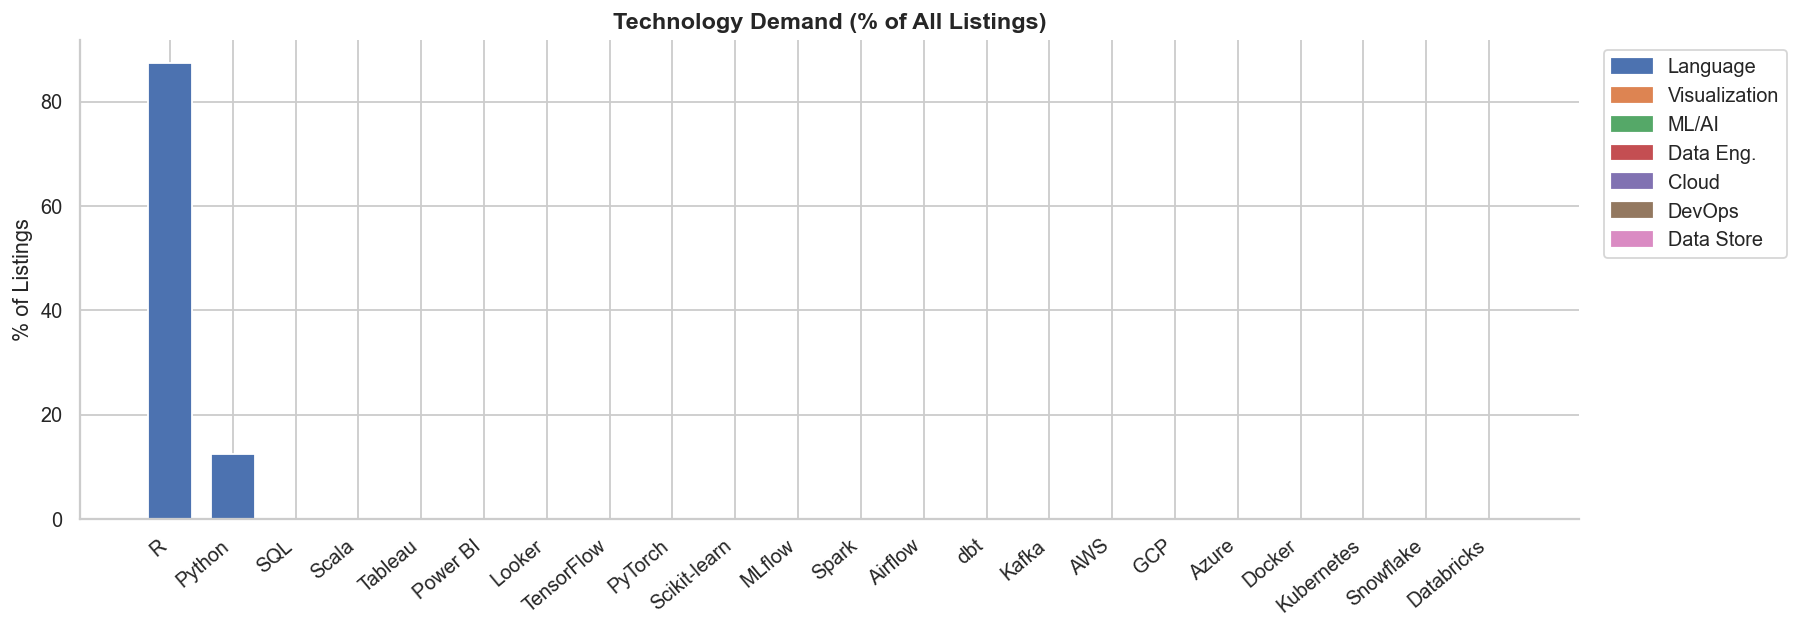

In [10]:
TECH = {
    'Python': 'Language', 'SQL': 'Language', 'R': 'Language', 'Scala': 'Language',
    'Tableau': 'Visualization', 'Power BI': 'Visualization', 'Looker': 'Visualization',
    'TensorFlow': 'ML/AI', 'PyTorch': 'ML/AI', 'Scikit-learn': 'ML/AI', 'MLflow': 'ML/AI',
    'Spark': 'Data Eng.', 'Airflow': 'Data Eng.', 'dbt': 'Data Eng.', 'Kafka': 'Data Eng.',
    'AWS': 'Cloud', 'GCP': 'Cloud', 'Azure': 'Cloud',
    'Docker': 'DevOps', 'Kubernetes': 'DevOps',
    'Snowflake': 'Data Store', 'Databricks': 'Data Store',
}

skills_text = df['skills'].str.lower().fillna('')
tech_rows = [
    {'tech': t, 'category': c, 'pct': round(skills_text.str.contains(t.lower(), regex=False).sum() / len(df) * 100, 1)}
    for t, c in TECH.items()
]
tech_df = pd.DataFrame(tech_rows).sort_values('pct', ascending=False)

CAT_COLORS = {
    'Language': '#4C72B0', 'Visualization': '#DD8452', 'ML/AI': '#55A868',
    'Data Eng.': '#C44E52', 'Cloud': '#8172B2', 'DevOps': '#937860', 'Data Store': '#DA8BC3',
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(tech_df['tech'], tech_df['pct'],
       color=tech_df['category'].map(CAT_COLORS), edgecolor='white', width=0.7)
ax.set_title('Technology Demand (% of All Listings)')
ax.set_ylabel('% of Listings')
plt.xticks(rotation=40, ha='right')

from matplotlib.patches import Patch
legend_handles = [Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('images/chart_technologies.png', bbox_inches='tight')
plt.show()

## Posting Trends Over Time

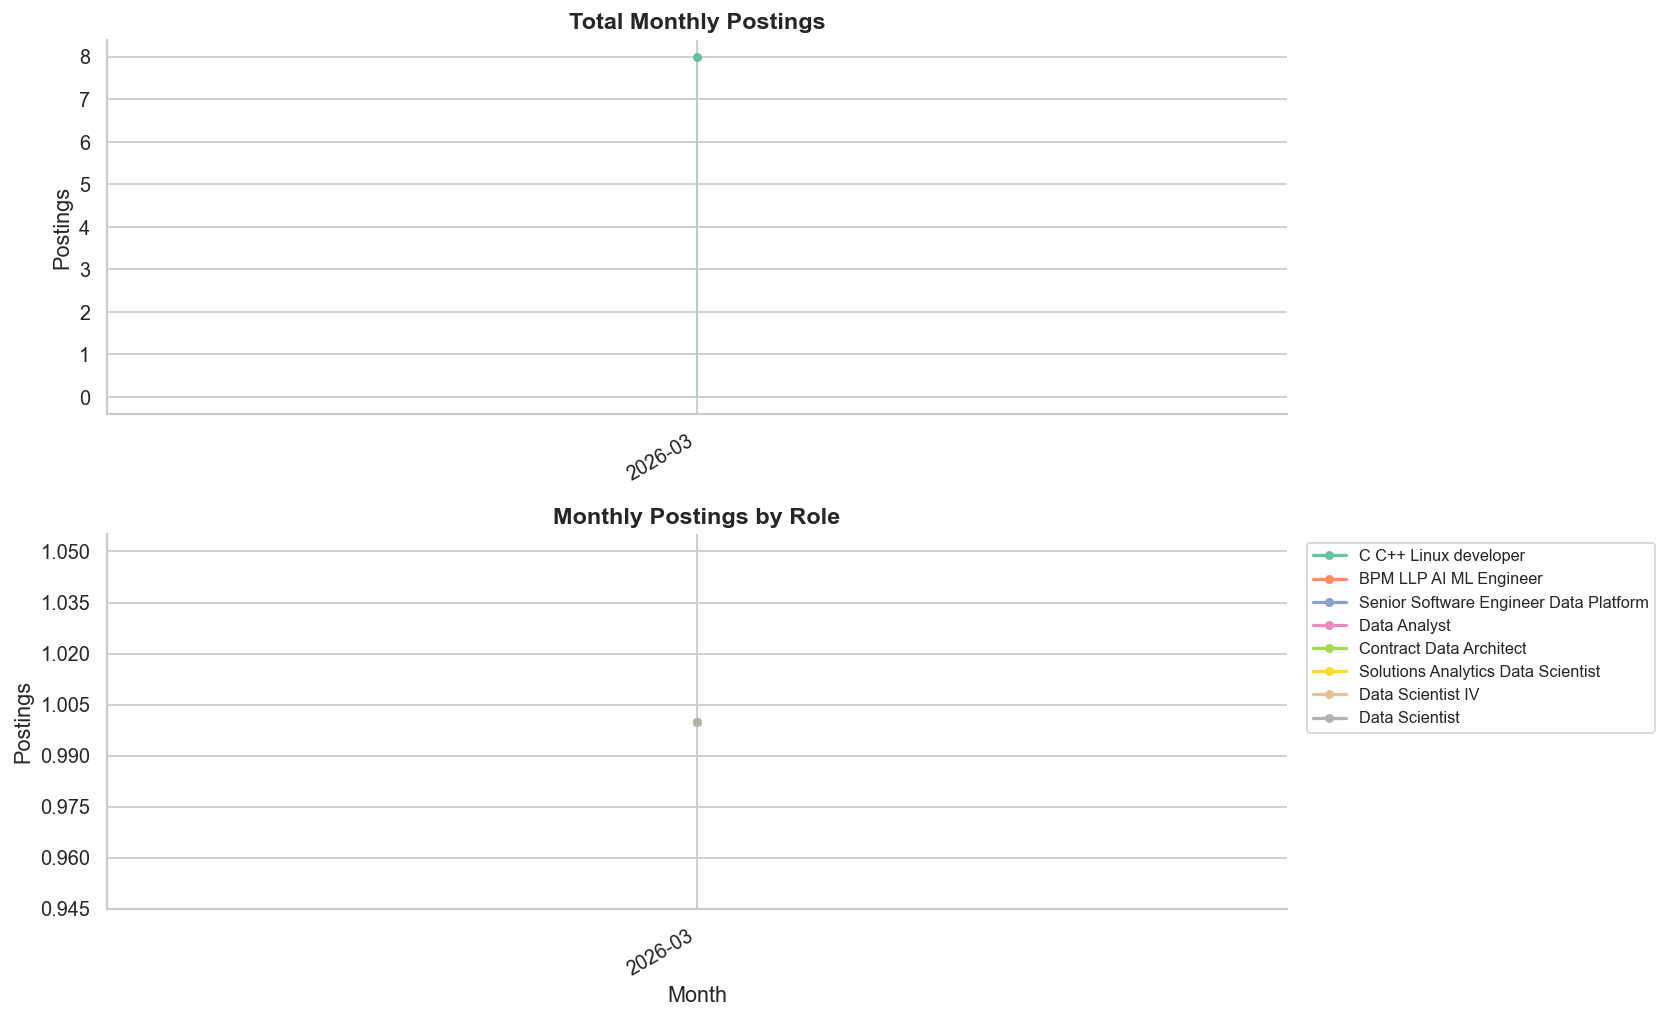

In [11]:
df['month'] = df['posting_date'].dt.to_period('M')
monthly = df.groupby('month').size().reset_index(name='count')
monthly['month_str'] = monthly['month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Total monthly postings
axes[0].fill_between(monthly['month_str'], monthly['count'], alpha=0.3, color=COLORS[0])
axes[0].plot(monthly['month_str'], monthly['count'], color=COLORS[0], linewidth=2, marker='o', markersize=4)
axes[0].set_title('Total Monthly Postings')
axes[0].set_ylabel('Postings')
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Per-role trends
monthly_role = df.groupby(['month', 'job_title']).size().unstack(fill_value=0).reset_index()
monthly_role['month_str'] = monthly_role['month'].astype(str)
for i, role in enumerate(df['job_title'].unique()):
    if role in monthly_role.columns:
        axes[1].plot(monthly_role['month_str'], monthly_role[role],
                     marker='o', markersize=4, linewidth=1.8, label=role, color=COLORS[i])

axes[1].set_title('Monthly Postings by Role')
axes[1].set_ylabel('Postings')
axes[1].set_xlabel('Month')
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('images/chart_trends.png', bbox_inches='tight')
plt.show()

## Summary

In [12]:
top_role   = df['job_title'].value_counts().idxmax()
top_skill  = top_skills.iloc[0]['skill']
top_loc    = df['location'].value_counts().idxmax()
avg_salary = df_sal['salary_mid'].mean()

print(f'Total listings   : {len(df)}')
print(f'Unique companies : {df["company"].nunique()}')
print(f'Most common role : {top_role}')
print(f'Top skill        : {top_skill}')
print(f'Top location     : {top_loc}')
print(f'Average salary   : ${avg_salary:,.0f}')

Total listings   : 8
Unique companies : 8
Most common role : C C++ Linux developer
Top skill        : engineering
Top location     : Remote
Average salary   : $75,000
